### BSAN 6070_Spring2026_ML_Final_Project
# Flight Delay Prediction
### Anthony's Individual Model: Logistic Regression - Top 6 Airport Route Version

**Goal:** Train a Logistic Regression model only on flights where both origin and destination are one of `ORD`, `ATL`, `DEN`, `DFW`, `CLT`, and `LAX`. This version excludes 2020 and uses the same feature groups as Prince and Alex, including engineered congestion features.


## 1. Setup & Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_score, recall_score, f1_score, accuracy_score
)
import joblib

RANDOM_STATE = 42
SAMPLE_FRAC = 0.40

print("Imports loaded successfully.")


Imports loaded successfully.


## 2. Data Loading - Top 6 Airport OD Routes
This notebook uses only routes where both `Origin` and `Dest` are in:

`ORD, ATL, DEN, DFW, CLT`

It uses the retained non-2020 years: **2018, 2019, 2021, and 2022**.

The file loaded below was pre-filtered from the full Parquet files and includes two leakage-free congestion proxy features:
- `origin_hourly_departures`
- `dest_hourly_arrivals`


In [2]:
DATA_PATH = "/Users/anthonyhanna/Documents/New project/team_data_6_airports/top6_airport_routes_excl2020_with_congestion.parquet"
TOP_AIRPORTS = ['ORD', 'ATL', 'DEN', 'DFW', 'CLT', 'LAX']
TARGET = 'ArrDel15'

df = pd.read_parquet(DATA_PATH)
df[TARGET] = df[TARGET].astype(int)

print(f"Loaded top 6 airport route dataset shape: {df.shape}")
print(f"Airport set: {TOP_AIRPORTS}")
print(f"Overall delay rate: {df[TARGET].mean():.4f}")
print()
print("Rows by year:")
print(df['Year'].value_counts().sort_index())

df.head(3)


Loaded top 6 airport route dataset shape: (532784, 18)
Airport set: ['ORD', 'ATL', 'DEN', 'DFW', 'CLT', 'LAX']
Overall delay rate: 0.2018

Rows by year:
Year
2018    118388
2019    180364
2021    148091
2022     85941
Name: count, dtype: int64


,ArrDel15,FlightDate,Year,Quarter,Month,DayofMonth,DayOfWeek,CRSDepTime,CRSArrTime,DepTimeBlk,Origin,Dest,Distance,DistanceGroup,Marketing_Airline_Network,Operating_Airline,origin_hourly_departures,dest_hourly_arrivals
0,0,2018-01-01,2018,1,1,1,1,1515.0,1822.0,1500-1559,ORD,ATL,606.0,3,DL,9E,4,5
1,0,2018-01-02,2018,1,1,2,2,1840.0,2145.0,1800-1859,ORD,ATL,606.0,3,DL,9E,2,3
2,0,2018-01-03,2018,1,1,3,3,725.0,826.0,0700-0759,ATL,ORD,606.0,3,DL,9E,5,2


## 3. Shared Target and Feature Set
This mirrors Prince and Alex's feature grouping so the model comparison stays fair.

The model uses temporal, schedule, route, airline, and congestion features. Departure features like `DepDelay`, `DepDel15`, and `TaxiOut` are listed as conditional features but are not included in this pre-departure prediction setup.


In [3]:
# CANDIDATE FEATURE GROUPS
TEMPORAL_FEATURES   = ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek']
SCHEDULE_FEATURES   = ['CRSDepTime', 'CRSArrTime', 'DepTimeBlk']
ROUTE_FEATURES      = ['Origin', 'Dest', 'Distance', 'DistanceGroup']
AIRLINE_FEATURES    = ['Marketing_Airline_Network', 'Operating_Airline']
CONGESTION_FEATURES = ['origin_hourly_departures', 'dest_hourly_arrivals']
DEPARTURE_FEATURES  = ['DepDelay', 'DepDel15', 'TaxiOut']  # conditional; not used here

ALL_CANDIDATES = (
    TEMPORAL_FEATURES + SCHEDULE_FEATURES +
    ROUTE_FEATURES + AIRLINE_FEATURES +
    CONGESTION_FEATURES
)

available_candidates = [c for c in ALL_CANDIDATES if c in df.columns]
X = df[available_candidates].copy()
y = df[TARGET].copy().astype(int)

print("Candidate features by group:")
for grp, feats in [
    ('Temporal', TEMPORAL_FEATURES),
    ('Schedule', SCHEDULE_FEATURES),
    ('Route', ROUTE_FEATURES),
    ('Airline', AIRLINE_FEATURES),
    ('Congestion', CONGESTION_FEATURES),
    ('Departure conditional', DEPARTURE_FEATURES)
]:
    print(f"  {grp}: {feats}")

print()
print("Actual features used:")
print(available_candidates)
print()
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Delay rate: {y.mean():.4f}")
print()
print("Missing values per feature:")
print(X.isnull().sum()[X.isnull().sum() > 0].sort_values(ascending=False))


Candidate features by group:
  Temporal: ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek']
  Schedule: ['CRSDepTime', 'CRSArrTime', 'DepTimeBlk']
  Route: ['Origin', 'Dest', 'Distance', 'DistanceGroup']
  Airline: ['Marketing_Airline_Network', 'Operating_Airline']
  Congestion: ['origin_hourly_departures', 'dest_hourly_arrivals']
  Departure conditional: ['DepDelay', 'DepDel15', 'TaxiOut']

Actual features used:
['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'CRSDepTime', 'CRSArrTime', 'DepTimeBlk', 'Origin', 'Dest', 'Distance', 'DistanceGroup', 'Marketing_Airline_Network', 'Operating_Airline', 'origin_hourly_departures', 'dest_hourly_arrivals']

Feature matrix shape: (532784, 16)
Target shape: (532784,)
Delay rate: 0.2018

Missing values per feature:
Series([], dtype: int64)


## 4. Exploratory Data Analysis Before Modeling
Before training Logistic Regression, we check the distribution across years, routes, airports, target class, and congestion features.


Rows by year:
Year
2018    118388
2019    180364
2021    148091
2022     85941
Name: count, dtype: int64

Delay rate by year:
Year
2018    0.1956
2019    0.2175
2021    0.1805
2022    0.2145
Name: ArrDel15, dtype: float64


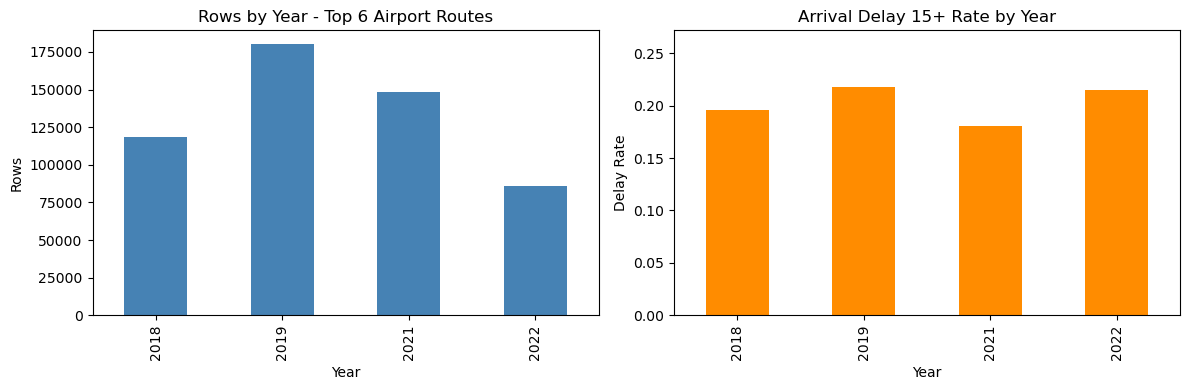

In [4]:
print("Rows by year:")
year_counts = df['Year'].value_counts().sort_index()
print(year_counts)

print()
print("Delay rate by year:")
delay_by_year = df.groupby('Year')[TARGET].mean().round(4)
print(delay_by_year)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

year_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rows by Year - Top 6 Airport Routes')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Rows')

delay_by_year.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Arrival Delay 15+ Rate by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Delay Rate')
axes[1].set_ylim(0, max(delay_by_year.max() * 1.25, 0.25))

plt.tight_layout()
plt.show()


Origin-Destination matrix:


Dest,ORD,ATL,DEN,DFW,CLT,LAX
Origin,,,,,,
ORD,0,22022,21524,20341,14483,23030
ATL,21953,0,19011,18774,17378,18006
DEN,21516,18974,0,18217,9457,25914
DFW,20542,18825,18054,0,10475,21176
CLT,14237,17413,9408,10439,0,6947
LAX,22947,17860,25807,21142,6912,0


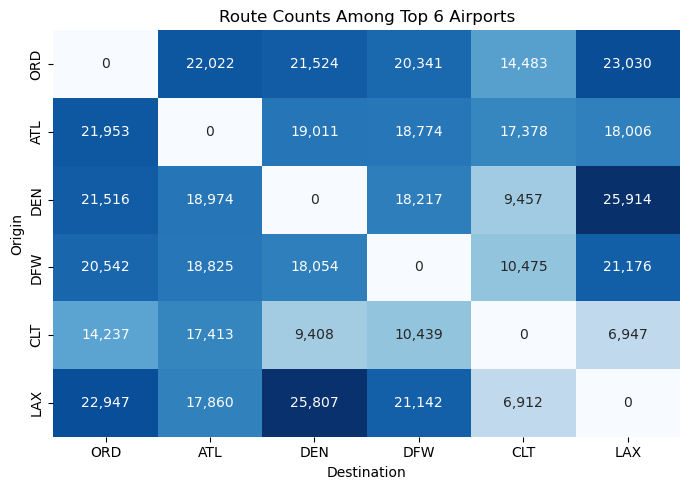


Top airlines in this subset:
Marketing_Airline_Network
AA    210246
UA    128956
DL    109621
WN     34770
NK     29729
F9     18061
AS      1218
VX       183
Name: count, dtype: int64


In [5]:
print("Origin-Destination matrix:")
od_matrix = pd.crosstab(df['Origin'], df['Dest']).reindex(index=TOP_AIRPORTS, columns=TOP_AIRPORTS, fill_value=0)
display(od_matrix)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(od_matrix, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Route Counts Among Top 6 Airports')
ax.set_xlabel('Destination')
ax.set_ylabel('Origin')
plt.tight_layout()
plt.show()

print()
print("Top airlines in this subset:")
print(df['Marketing_Airline_Network'].value_counts().head(10))


Numeric and congestion feature summary:


,count,mean,std,min,25%,50%,75%,max
Distance,532784.0,1013.690735,482.661346,226.0,641.0,862.0,1235.0,2125.0
CRSDepTime,532784.0,1310.956543,502.560852,2.0,905.0,1310.0,1720.0,2359.0
CRSArrTime,532784.0,1491.425903,530.450562,1.0,1120.0,1521.0,1923.0,2359.0
origin_hourly_departures,532784.0,4.959556,1.939370,1.0,4.0,5.0,6.0,12.0
dest_hourly_arrivals,532784.0,4.788406,1.967991,1.0,3.0,5.0,6.0,13.0


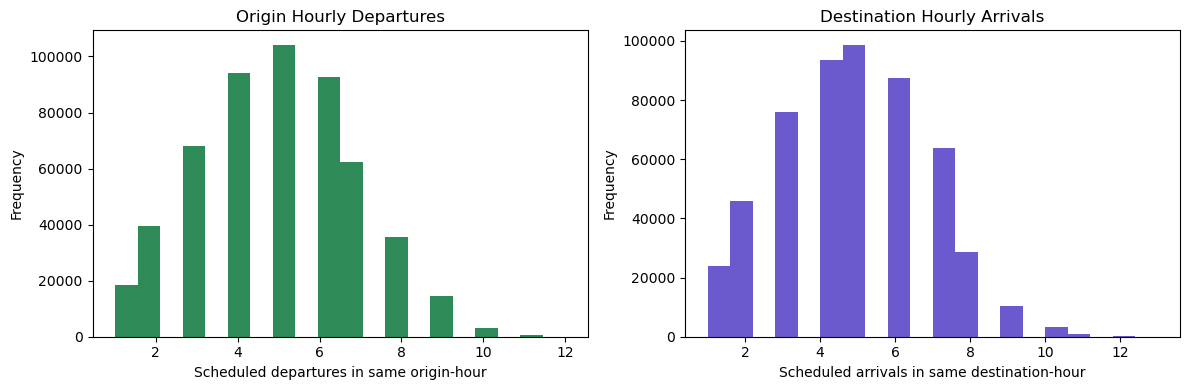


Missing values in modeling data:
No missing values in selected modeling columns.


In [6]:
numeric_cols_for_eda = [
    'Distance', 'CRSDepTime', 'CRSArrTime',
    'origin_hourly_departures', 'dest_hourly_arrivals'
]

numeric_summary = df[numeric_cols_for_eda].describe().T
print("Numeric and congestion feature summary:")
display(numeric_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['origin_hourly_departures'].plot(kind='hist', bins=20, ax=axes[0], color='seagreen')
axes[0].set_title('Origin Hourly Departures')
axes[0].set_xlabel('Scheduled departures in same origin-hour')

df['dest_hourly_arrivals'].plot(kind='hist', bins=20, ax=axes[1], color='slateblue')
axes[1].set_title('Destination Hourly Arrivals')
axes[1].set_xlabel('Scheduled arrivals in same destination-hour')

plt.tight_layout()
plt.show()

missing_summary = df[[TARGET] + available_candidates].isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
print()
print("Missing values in modeling data:")
print(missing_summary if len(missing_summary) else "No missing values in selected modeling columns.")


## 5. Train / Test Split
Use the same split settings as the team.

This six-airport subset is small enough to train Logistic Regression on the full training split, but the same capped training safeguard remains in the code.


In [7]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Training cap stays here as a safety guard, but this subset should train on all rows.
TRAIN_CAP = 500_000

train_pool = X_train_full.copy()
train_pool[TARGET] = y_train_full.values

if len(train_pool) > TRAIN_CAP:
    train_frac = TRAIN_CAP / len(train_pool)
    train_sample = (
        train_pool
        .groupby(['Year', TARGET], group_keys=False)
        .sample(frac=train_frac, random_state=RANDOM_STATE)
    )
else:
    train_sample = train_pool

X_train = train_sample.drop(columns=[TARGET])
y_train = train_sample[TARGET].astype(int)

print(f"Full train pool size : {X_train_full.shape[0]:,}")
print(f"LR train subset size : {X_train.shape[0]:,}")
print(f"Full test size       : {X_test.shape[0]:,}")
print(f"Train delay rate     : {y_train.mean():.4f}")
print(f"Test delay rate      : {y_test.mean():.4f}")
print()
print("LR train subset by year:")
print(X_train.assign(ArrDel15=y_train).groupby('Year')['ArrDel15'].agg(['count', 'mean']).round(4))


Full train pool size : 426,227
LR train subset size : 426,227
Full test size       : 106,557
Train delay rate     : 0.2018
Test delay rate      : 0.2018

LR train subset by year:
       count    mean
Year                
2018   94480  0.1949
2019  144275  0.2176
2021  118543  0.1809
2022   68929  0.2145


## 6. Logistic Regression Preprocessing
For Logistic Regression, we need:
- median imputation for numeric columns
- one-hot encoding for categorical columns
- feature scaling for numeric columns

The congestion features are numeric and are scaled with the other numeric variables.


In [8]:
categorical_cols = ['Marketing_Airline_Network', 'Operating_Airline', 'Origin', 'Dest', 'DepTimeBlk']
categorical_cols = [c for c in categorical_cols if c in X_train.columns]
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'CRSDepTime', 'CRSArrTime', 'Distance', 'DistanceGroup', 'origin_hourly_departures', 'dest_hourly_arrivals']
Categorical columns: ['Marketing_Airline_Network', 'Operating_Airline', 'Origin', 'Dest', 'DepTimeBlk']


## 7. Model Choice Justification

I chose **Logistic Regression** because our prediction is a simple yes/no outcome: whether a flight arrives 15 minutes or more late. It is a good fit because it is easy to explain, runs quickly, and gives us a strong baseline to compare against Prince's and Alex's more advanced models.

Logistic Regression also helps us understand which features are connected to delays, such as airport route, airline, scheduled time, day of week, and congestion. Since my model focuses on the six-airport route network, it gives us a cleaner and more focused version of the delay prediction problem.

Overall, this model is useful because it is practical, interpretable, and fair to compare against Random Forest and XGBoost/Gradient Boosting.


## 8. Baseline Logistic Regression Model
This uses stochastic gradient descent with logistic loss. It is still a Logistic Regression model, but it trains quickly on the six-airport route subset.


In [9]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(
        loss='log_loss',
        max_iter=5,
        tol=1e-3,
        class_weight='balanced',
        average=True,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=2,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr, target_names=['On Time', 'Delayed']))
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")


=== Logistic Regression Results ===
              precision    recall  f1-score   support

     On Time       0.85      0.56      0.68     85050
     Delayed       0.26      0.62      0.37     21507

    accuracy                           0.57    106557
   macro avg       0.56      0.59      0.52    106557
weighted avg       0.73      0.57      0.62    106557

Accuracy : 0.5730
Precision: 0.2629
Recall   : 0.6188
F1 Score : 0.3691
ROC-AUC  : 0.6217


## 9. Lightweight Hyperparameter Tuning

Because Logistic Regression does not have tree-based settings like `n_estimators` or `max_depth`, tuning focuses on regularization strength, penalty type, class weighting, and the probability threshold used to classify a flight as delayed.


In [10]:
TUNE_SIZE = 120_000
THRESHOLDS = [0.35, 0.40, 0.45, 0.50, 0.55]

if len(X_train) > TUNE_SIZE:
    X_tune, _, y_tune, _ = train_test_split(
        X_train, y_train,
        train_size=TUNE_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE
    )
else:
    X_tune = X_train.copy()
    y_tune = y_train.copy()

X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_tune, y_tune,
    test_size=0.25,
    stratify=y_tune,
    random_state=RANDOM_STATE
)

tuning_configs = [
    {'alpha': 0.0001, 'penalty': 'l2', 'class_weight': 'balanced'},
    {'alpha': 0.0005, 'penalty': 'l2', 'class_weight': 'balanced'},
    {'alpha': 0.0010, 'penalty': 'l2', 'class_weight': 'balanced'},
    {'alpha': 0.0005, 'penalty': 'l1', 'class_weight': 'balanced'},
    {'alpha': 0.0005, 'penalty': 'elasticnet', 'class_weight': 'balanced'},
    {'alpha': 0.0005, 'penalty': 'l2', 'class_weight': None},
]

tuning_rows = []
for config in tuning_configs:
    candidate_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', SGDClassifier(
            loss='log_loss',
            alpha=config['alpha'],
            penalty=config['penalty'],
            l1_ratio=0.15,
            max_iter=8,
            tol=1e-3,
            class_weight=config['class_weight'],
            average=True,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=2,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])

    candidate_pipeline.fit(X_tune_train, y_tune_train)
    val_prob = candidate_pipeline.predict_proba(X_tune_val)[:, 1]
    val_auc = roc_auc_score(y_tune_val, val_prob)

    for threshold in THRESHOLDS:
        val_pred = (val_prob >= threshold).astype(int)
        tuning_rows.append({
            'alpha': config['alpha'],
            'penalty': config['penalty'],
            'class_weight': str(config['class_weight']),
            'threshold': threshold,
            'accuracy': accuracy_score(y_tune_val, val_pred),
            'precision': precision_score(y_tune_val, val_pred, zero_division=0),
            'recall': recall_score(y_tune_val, val_pred),
            'f1': f1_score(y_tune_val, val_pred),
            'roc_auc': val_auc
        })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ['f1', 'roc_auc', 'recall'],
    ascending=False
)

print('Top tuning results ranked by F1 score:')
print(tuning_results.head(10).round(4).to_string(index=False))


Top tuning results ranked by F1 score:
 alpha penalty class_weight  threshold  accuracy  precision  recall     f1  roc_auc
0.0005      l2     balanced       0.50    0.5769     0.2660  0.6228 0.3727   0.6220
0.0001      l2     balanced       0.45    0.5369     0.2563  0.6809 0.3725   0.6212
0.0010      l2     balanced       0.50    0.5803     0.2665  0.6162 0.3721   0.6214
0.0001      l2     balanced       0.50    0.5741     0.2641  0.6216 0.3707   0.6212
0.0005      l2     balanced       0.45    0.4994     0.2482  0.7295 0.3704   0.6220
0.0010      l2     balanced       0.45    0.4893     0.2460  0.7409 0.3693   0.6214
0.0001      l2     balanced       0.40    0.4969     0.2472  0.7296 0.3692   0.6212
0.0001      l2     balanced       0.35    0.4550     0.2397  0.7828 0.3670   0.6212
0.0001      l2     balanced       0.55    0.6127     0.2726  0.5509 0.3647   0.6212
0.0005      l2     balanced       0.40    0.4167     0.2326  0.8221 0.3626   0.6220


## 10. Tuned Logistic Regression Model

The best tuning setting is refit on the full training set, then evaluated on the held-out test set. The rest of the notebook uses this tuned model.


In [11]:
best_row = tuning_results.iloc[0]
best_class_weight = None if best_row['class_weight'] == 'None' else best_row['class_weight']
best_threshold = float(best_row['threshold'])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(
        loss='log_loss',
        alpha=float(best_row['alpha']),
        penalty=best_row['penalty'],
        l1_ratio=0.15,
        max_iter=8,
        tol=1e-3,
        class_weight=best_class_weight,
        average=True,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=2,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

lr_pipeline.fit(X_train, y_train)

y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= best_threshold).astype(int)

print('=== Tuned Logistic Regression Results ===')
print('Best tuning settings:')
print(best_row[['alpha', 'penalty', 'class_weight', 'threshold']].to_string())
print()
print(classification_report(y_test, y_pred_lr, target_names=['On Time', 'Delayed']))
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")


=== Tuned Logistic Regression Results ===
Best tuning settings:
alpha             0.0005
penalty               l2
class_weight    balanced
threshold            0.5

              precision    recall  f1-score   support

     On Time       0.85      0.56      0.68     85050
     Delayed       0.26      0.62      0.37     21507

    accuracy                           0.57    106557
   macro avg       0.56      0.59      0.52    106557
weighted avg       0.73      0.57      0.61    106557

Accuracy : 0.5723
Precision: 0.2630
Recall   : 0.6206
F1 Score : 0.3694
ROC-AUC  : 0.6209


## 11. Confusion Matrix


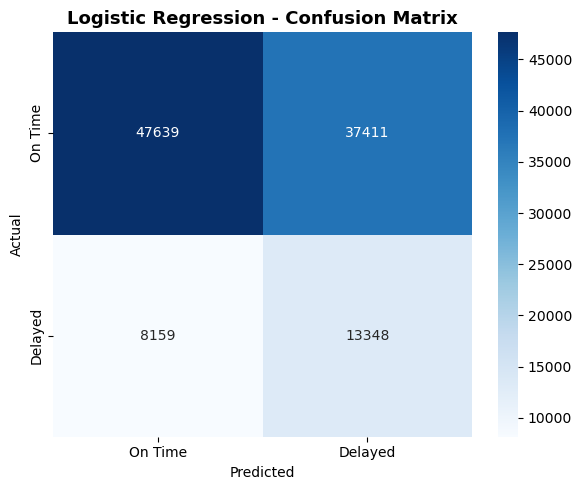

In [12]:
cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'], ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()


## 12. ROC Curve


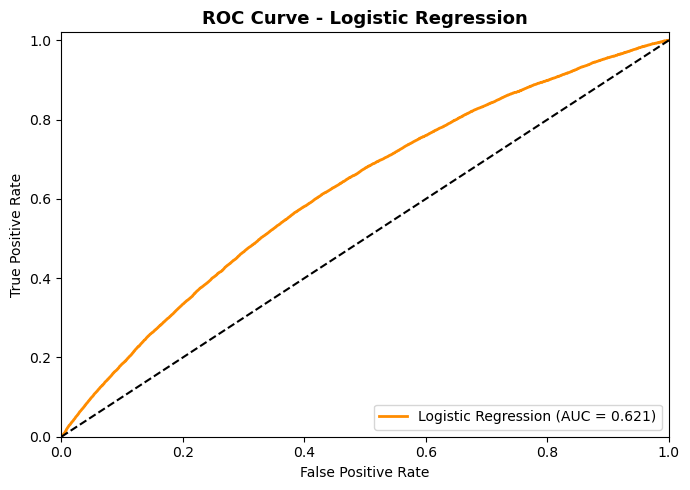

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Logistic Regression', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 13. Coefficient Interpretation
This is one of the advantages of Logistic Regression.


Top 15 features by absolute coefficient:
                          Feature  Coefficient
        cat__Operating_Airline_DL    -0.468746
        cat__DepTimeBlk_0600-0659    -0.460636
        cat__DepTimeBlk_0700-0759    -0.305195
        cat__Operating_Airline_G7     0.280233
        cat__DepTimeBlk_2100-2159     0.242149
        cat__DepTimeBlk_1800-1859     0.238259
                  cat__Origin_ORD     0.232574
        cat__DepTimeBlk_1600-1659     0.230253
        cat__DepTimeBlk_1700-1759     0.229564
        cat__DepTimeBlk_1500-1559     0.213491
cat__Marketing_Airline_Network_DL     0.208452
        cat__DepTimeBlk_1900-1959     0.196219
                  cat__Origin_LAX    -0.194752
                  num__CRSDepTime     0.184419
        cat__Operating_Airline_OH     0.181418


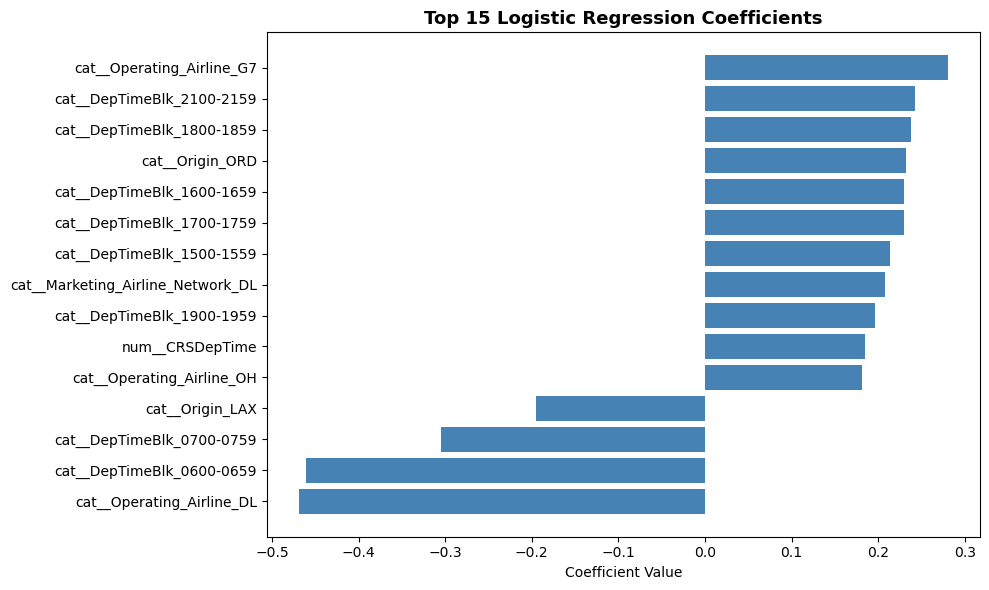

In [14]:
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = lr_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)
}).sort_values('AbsCoefficient', ascending=False)

print("Top 15 features by absolute coefficient:")
print(coef_df[['Feature', 'Coefficient']].head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_coef = coef_df.head(15).sort_values('Coefficient')
ax.barh(top_coef['Feature'], top_coef['Coefficient'], color='steelblue')
ax.set_title('Top 15 Logistic Regression Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


## 14. Save Artifacts


In [15]:
joblib.dump(lr_pipeline, 'logistic_flight_delay_model.sav')
joblib.dump(available_candidates, 'logistic_feature_names.sav')
joblib.dump(best_threshold, 'logistic_decision_threshold.sav')

print("Saved: logistic_flight_delay_model.sav")
print("Saved: logistic_feature_names.sav")
print("Saved: logistic_decision_threshold.sav")


Saved: logistic_flight_delay_model.sav
Saved: logistic_feature_names.sav
Saved: logistic_decision_threshold.sav
